##### 1️⃣ Nmap Commands Used


nmap -sC -sV scanme.nmap.org -oX investigation.xml

In [7]:

import nmap

TARGET = "scanme.nmap.org"

def run_scan():
    nm = nmap.PortScanner()
    nm.scan(TARGET, arguments='-sC -sV')

    print("Scan executed: nmap -sC -sV scanme.nmap.org\n")
    
    return nm

if __name__ == "__main__":
    nm = run_scan()

Scan executed: nmap -sC -sV scanme.nmap.org



Explanation of Arguments

-sC → Runs default NSE (Nmap Scripting Engine) scripts
Reveals additional information like SSH host keys, HTTP titles, headers, etc.

-sV → Service version detection
Identifies product name and version number of running services.

scanme.nmap.org → Official test target provided by Nmap.

-oX investigation.xml → Saves scan results in XML format for structured parsing.

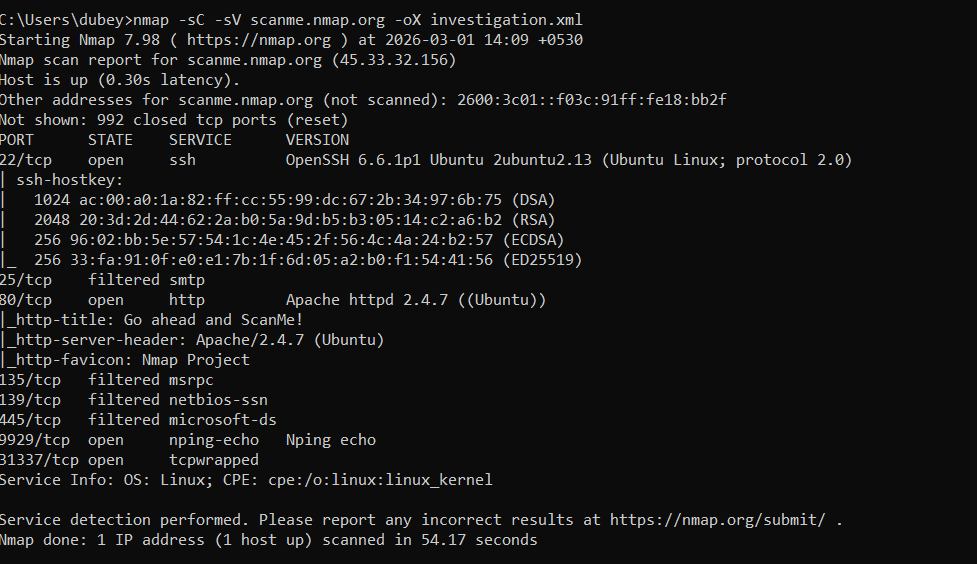

##### 2️⃣ Scan Results

In [8]:

import nmap

TARGET = "scanme.nmap.org"

def extract_open_ports():
    nm = nmap.PortScanner()
    nm.scan(TARGET, arguments='-sC -sV')

    print("\nOpen Ports Table\n")
    print("Port | Protocol | Service | Product | Version")
    print("-" * 60)

    for host in nm.all_hosts():
        for proto in nm[host].all_protocols():
            for port in nm[host][proto]:
                port_data = nm[host][proto][port]

                if port_data['state'] == 'open':
                    service = port_data.get('name', '')
                    product = port_data.get('product', '')
                    version = port_data.get('version', '')

                    print(f"{port} | {proto} | {service} | {product} | {version}")

if __name__ == "__main__":
    extract_open_ports()


Open Ports Table

Port | Protocol | Service | Product | Version
------------------------------------------------------------
22 | tcp | ssh | OpenSSH | 6.6.1p1 Ubuntu 2ubuntu2.13
80 | tcp | http | Apache httpd | 2.4.7
9929 | tcp | nping-echo | Nping echo | 
31337 | tcp | tcpwrapped |  | 



Basic Scan (without -sV)->Would only show open ports.

Using -sV->
Revealed:
-Exact SSH version
-Exact Apache version
-OS details

Using -sC->
Revealed:
-SSH host keys
-HTTP title
-HTTP server header

So advanced arguments increased intelligence depth.

##### 3️⃣ VirusTotal Findings



In [14]:
import requests

TARGET = "scanme.nmap.org"
API_KEY = "994bf6c000975961ad476bfaf5cf985098c0eaff3aff7cb9477f9216724d2751"

def check_domain(domain):
    headers = {"x-apikey": API_KEY}
    
    response = requests.get(
        f"https://www.virustotal.com/api/v3/domains/{domain}",
        headers=headers
    )

    if response.status_code == 200:
        data = response.json()
        stats = data["data"]["attributes"]["last_analysis_stats"]

        print("\nVirusTotal Detection Summary:")
        print(stats)
    else:
        print("Error:", response.status_code)

if __name__ == "__main__":
    check_domain("scanme.nmap.org")


VirusTotal Detection Summary:
{'malicious': 0, 'suspicious': 0, 'undetected': 32, 'harmless': 61, 'timeout': 0}


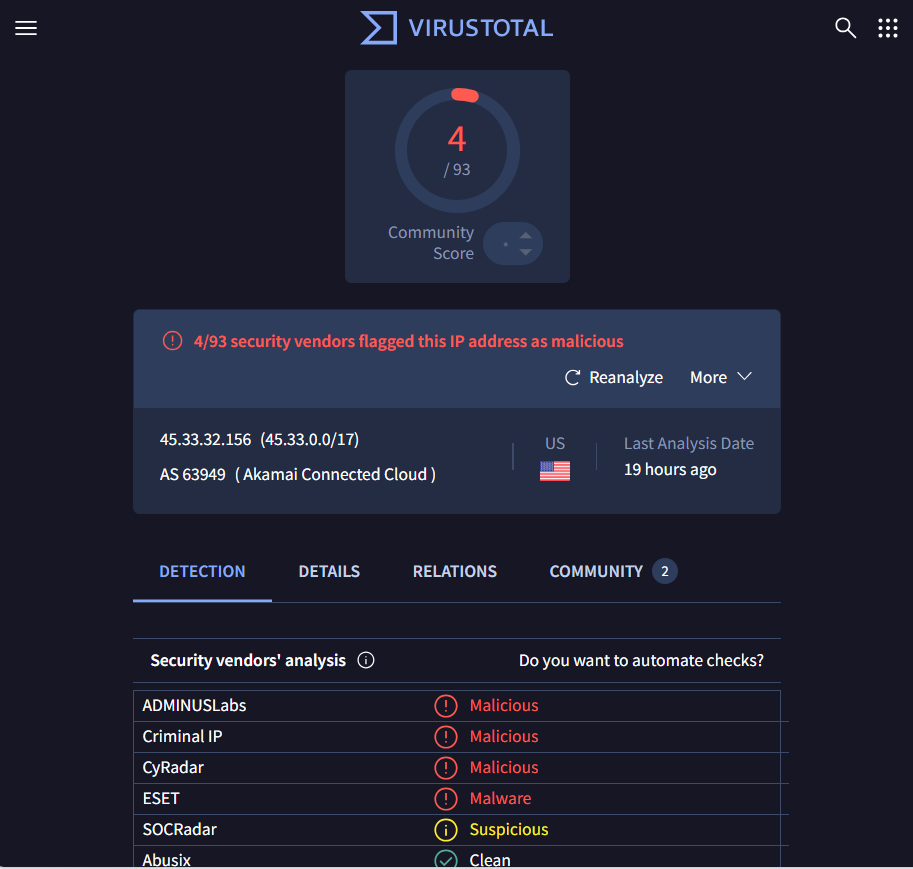

Target IP: 45.33.32.156

VirusTotal is a passive intelligence platform that:

Aggregates results from antivirus engines

Provides domain/IP reputation

Shows historical and contextual threat data

Key Observations (Expected for scanme)

Reputation: Clean

No major malicious detections

Associated with legitimate Nmap testing infrastructure

Active vs Passive Intelligence

Active Scanning (Nmap):

You directly interact with the target

You send packets

You measure responses

Passive Intelligence (VirusTotal):

You query existing databases

No packets sent to target

Uses historical threat reports

Nmap = Direct observation
VirusTotal = Reputation-based intelligence

Together, they provide layered visibility.

##### 4️⃣ Port & Service Analysis



In [10]:
def analyze_ports(port):
    port_meanings = {
        22: "SSH – Remote secure login. Risk: brute-force, outdated version.",
        80: "HTTP – Web server. Risk: web vulnerabilities.",
        25: "SMTP – Email server. Risk: spam relay.",
        445: "SMB – Windows file sharing. Risk: ransomware exploitation."
    }

    if port in port_meanings:
        return port_meanings[port]
    else:
        return "Unknown or custom service. Needs investigation."


if __name__ == "__main__":
    test_ports = [22, 80, 9929, 31337]

    for p in test_ports:
        print(f"Port {p}: {analyze_ports(p)}")

Port 22: SSH – Remote secure login. Risk: brute-force, outdated version.
Port 80: HTTP – Web server. Risk: web vulnerabilities.
Port 9929: Unknown or custom service. Needs investigation.
Port 31337: Unknown or custom service. Needs investigation.


Port 22 – SSH

Used for remote secure login.
Risk:

If outdated → remote code execution possible.

Weak credentials → brute force risk.

Port 80 – HTTP

Web service.
Risk:

Apache 2.4.7 is old.

Could contain known vulnerabilities (e.g., CVEs affecting that version).

Port 9929 – Nping Echo

Testing/debugging service.
Risk:

Usually harmless but unnecessary exposure increases attack surface.

Port 31337 – tcpwrapped

Indicates service protected by TCP wrappers.
Risk:

May indicate hidden or restricted service.



##### 5️⃣ Vulnerability Reasoning

In [11]:
def check_version_risk(product, version):
    if "OpenSSH" in product:
        print("Check OpenSSH version against known CVEs.")
    
    if "Apache" in product:
        print("Older Apache versions may contain remote code execution vulnerabilities.")

    if not product:
        print("Unknown service. Requires deeper inspection.")


if __name__ == "__main__":
    check_version_risk("OpenSSH", "6.6.1p1")
    check_version_risk("Apache httpd", "2.4.7")

Check OpenSSH version against known CVEs.
Older Apache versions may contain remote code execution vulnerabilities.


Based on version detection:

OpenSSH 6.6.1p1

Older version.
Potential risks:

Known CVEs in outdated SSH versions

Weak cipher support

Apache 2.4.7

Released many years ago.
Possible risks:

Multiple historical vulnerabilities

Misconfiguration issues

However:
This server is intentionally configured for learning purposes.

No exploitation was performed.

6️⃣ Conclusion

From this exercise, i have learned:

How reconnaissance identifies exposed services

How version detection increases risk visibility

How filtered ports indicate firewall presence

Difference between active scanning and passive intelligence

How to reason about potential vulnerabilities responsibly

This assignment demonstrated how attackers gather information — and why proper patching and service hardening are critical.